# Cross-Validation and Model Evaluation Techniques

Notebook ini membahas **cross-validation** dan **model evaluation techniques** menggunakan scikit-learn. Fokus utama chapter ini adalah bagaimana mengevaluasi performa model secara lebih adil, memilih model terbaik, melakukan tuning hyperparameter, serta menilai kemampuan generalisasi model terhadap data yang belum pernah dilihat.

Materi utama:
- Introduction to cross-validation
- K-Fold dan Stratified K-Fold
- Advanced cross-validation methods
- Leave-One-Out Cross-Validation
- Nested Cross-Validation
- Model evaluation metrics
- Implementing cross-validation in scikit-learn
- Model selection techniques
- GridSearchCV dan RandomizedSearchCV
- Learning curve dan validation curve
- Evaluating model generalizability

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami mengapa model evaluation tidak cukup hanya menggunakan satu train-test split.
- Menjelaskan konsep K-Fold Cross-Validation.
- Membedakan K-Fold dan Stratified K-Fold.
- Mengimplementasikan cross-validation manual dan high-level API scikit-learn.
- Menggunakan `cross_val_score()` dan `cross_validate()`.
- Menggunakan Leave-One-Out Cross-Validation untuk dataset kecil.
- Memahami konsep Nested Cross-Validation agar tuning tidak menyebabkan data leakage.
- Mengevaluasi model menggunakan accuracy, precision, recall, F1-score, MSE, RMSE, dan R².
- Menggunakan GridSearchCV dan RandomizedSearchCV untuk model selection.
- Menggunakan learning curve dan validation curve untuk mengevaluasi generalisasi model.
- Menganalisis underfitting, overfitting, dan diminishing returns pada penambahan data.

## Persiapan Library

Cell berikut memuat seluruh library yang digunakan. Warning diabaikan agar output notebook tetap rapi ketika dijalankan.

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import loguniform

from sklearn.datasets import make_classification, load_diabetes
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve,
    validation_curve
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(2024)
pd.set_option("display.max_columns", 120)

## Ringkasan Chapter

Model machine learning tidak pernah benar-benar sempurna. Walaupun model tampak bagus pada data training, performanya dapat menurun ketika menerima data baru. Hal ini dapat terjadi karena noise, perubahan distribusi data, overfitting, pemilihan hyperparameter yang tidak tepat, atau evaluasi yang terlalu optimistis.

Cross-validation digunakan untuk memperkirakan kemampuan model dalam melakukan generalisasi. Alih-alih hanya membagi data satu kali menjadi training dan testing, cross-validation membagi data ke beberapa fold, lalu melatih dan mengevaluasi model beberapa kali.

Topik utama pada chapter ini:

| Topik | Inti Pembahasan |
|---|---|
| K-Fold Cross-Validation | Membagi data menjadi beberapa fold untuk evaluasi berulang |
| Stratified K-Fold | Menjaga proporsi kelas pada setiap fold |
| LOOCV | Menggunakan satu data sebagai test set pada setiap iterasi |
| Nested CV | Memisahkan proses tuning dan evaluasi agar tidak data leakage |
| Model Metrics | Menggunakan metrik sesuai konteks masalah |
| GridSearchCV | Exhaustive search untuk hyperparameter tuning |
| RandomizedSearchCV | Sampling acak dari distribusi parameter |
| Learning Curve | Melihat pengaruh ukuran data training |
| Validation Curve | Melihat pengaruh hyperparameter terhadap performa |

## Introduction to Cross-Validation

Cross-validation adalah teknik evaluasi model yang digunakan untuk mengukur seberapa baik model dapat bekerja pada data yang belum pernah dilihat. Jika hanya menggunakan satu train-test split, hasil evaluasi bisa sangat bergantung pada pembagian data tersebut.

Misalnya, jika test set kebetulan mudah, score model terlihat tinggi. Jika test set kebetulan sulit, score model terlihat rendah. Cross-validation mengurangi ketergantungan terhadap satu pembagian data dengan melakukan training dan evaluasi berulang pada beberapa subset data.

Alur umum cross-validation:

1. Dataset dibagi menjadi beberapa fold.
2. Model dilatih pada sebagian fold.
3. Model diuji pada fold yang tersisa.
4. Proses diulang sampai setiap fold pernah menjadi validation/test fold.
5. Score rata-rata digunakan sebagai estimasi performa model.

## Rumus Rata-Rata Skor Cross-Validation

Jika cross-validation menghasilkan skor pada $k$ fold, maka skor rata-rata dihitung sebagai:

$$
CV\ Score = \frac{1}{k}\sum_{i=1}^{k} score_i
$$

Keterangan:

- $k$ = jumlah fold
- $score_i$ = skor model pada fold ke-$i$
- $CV\ Score$ = rata-rata performa model dari seluruh fold

Selain rata-rata, standar deviasi skor juga penting karena menunjukkan stabilitas performa model antar fold.

$$
CV\ Std = \sqrt{\frac{1}{k}\sum_{i=1}^{k}(score_i-\bar{score})^2}
$$

## K-Fold Cross-Validation

K-Fold Cross-Validation membagi dataset menjadi $k$ bagian. Pada setiap iterasi, satu fold digunakan sebagai validation set, sedangkan sisanya digunakan untuk training.

Jika $k=5$, maka proses training dan evaluasi dilakukan sebanyak 5 kali.

Kelebihan K-Fold:
- Lebih stabil dibanding single train-test split.
- Semua data mendapat kesempatan menjadi validation set.
- Cocok untuk banyak kasus supervised learning.

Keterbatasan:
- Tidak selalu menjaga distribusi kelas.
- Kurang ideal untuk dataset sangat imbalanced.
- Lebih mahal secara komputasi dibanding satu train-test split.

## Rumus Pembagian K-Fold

Jika dataset memiliki $n$ sampel dan dibagi menjadi $k$ fold, maka ukuran setiap fold kira-kira:

$$
Fold\ Size \approx \frac{n}{k}
$$

Pada setiap iterasi:

$$
Training\ Size \approx n - \frac{n}{k}
$$

$$
Validation\ Size \approx \frac{n}{k}
$$

Contoh: jika $n=500$ dan $k=5$, maka setiap validation fold berisi sekitar 100 sampel dan training fold berisi sekitar 400 sampel.

## Membuat Dataset Klasifikasi

Dataset sintetis dibuat menggunakan `make_classification`. Dataset ini digunakan untuk membandingkan K-Fold dan Stratified K-Fold.

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    n_classes=2,
    random_state=2024
)

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Distribusi kelas:", np.bincount(y))

Shape X: (500, 10)
Shape y: (500,)
Distribusi kelas: [250 250]


## Visualisasi Distribusi Kelas

Sebelum cross-validation, distribusi kelas perlu diperiksa. Jika kelas tidak seimbang, Stratified K-Fold biasanya lebih aman daripada K-Fold biasa.

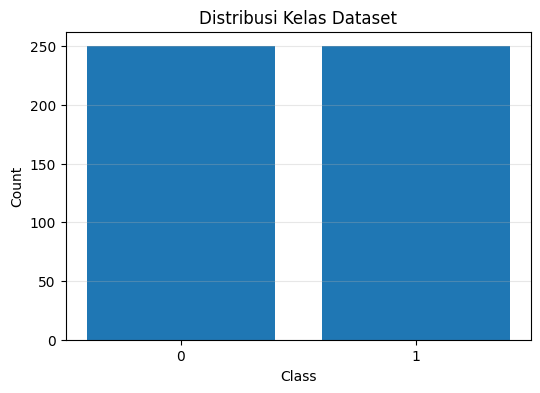

0    250
1    250
Name: count, dtype: int64

In [3]:
class_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Distribusi Kelas Dataset")
plt.grid(axis="y", alpha=0.3)
plt.show()

class_counts

## Implementasi Manual K-Fold

Contoh berikut menunjukkan cara melakukan K-Fold secara eksplisit menggunakan loop. Tujuannya agar proses cross-validation terlihat jelas.

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=2024)

accuracies_kfold = []
fold_details = []

for fold, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_fold, y_train_fold)

    y_pred_fold = model.predict(X_test_fold)
    acc = accuracy_score(y_test_fold, y_pred_fold)
    accuracies_kfold.append(acc)

    fold_details.append({
        "fold": fold,
        "train_size": len(train_index),
        "test_size": len(test_index),
        "test_class_0": np.sum(y_test_fold == 0),
        "test_class_1": np.sum(y_test_fold == 1),
        "accuracy": acc
    })

kfold_df = pd.DataFrame(fold_details)

print(f"Average accuracy (KFold): {np.mean(accuracies_kfold):.3f}")
print(f"Std accuracy (KFold): {np.std(accuracies_kfold):.3f}")

kfold_df

Average accuracy (KFold): 0.756
Std accuracy (KFold): 0.063


,fold,train_size,test_size,test_class_0,test_class_1,accuracy
0,1,400,100,48,52,0.72
1,2,400,100,53,47,0.72
2,3,400,100,46,54,0.88
3,4,400,100,49,51,0.71
4,5,400,100,54,46,0.75


## Analisis K-Fold

Hasil K-Fold menunjukkan akurasi pada setiap fold. Jika akurasi antar fold berbeda jauh, artinya performa model sensitif terhadap pembagian data. Ini bisa menjadi tanda dataset kecil, noise tinggi, distribusi kelas tidak seimbang, atau model kurang stabil.

Pada classification problem, K-Fold biasa dapat menghasilkan fold dengan distribusi kelas yang tidak selalu proporsional.

## Stratified K-Fold Cross-Validation

Stratified K-Fold menjaga proporsi kelas pada setiap fold. Teknik ini penting untuk klasifikasi, terutama ketika dataset imbalanced.

Jika dataset memiliki 70% kelas 0 dan 30% kelas 1, maka setiap fold juga akan berusaha mempertahankan proporsi tersebut.

Kelebihan Stratified K-Fold:
- Lebih representatif untuk klasifikasi.
- Mengurangi risiko fold yang terlalu berat ke satu kelas.
- Memberikan estimasi performa yang lebih adil pada dataset imbalanced.

In [5]:
strat_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

accuracies_strat = []
strat_fold_details = []

for fold, (train_index, test_index) in enumerate(strat_kf.split(X, y), start=1):
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_fold, y_train_fold)

    y_pred_fold = model.predict(X_test_fold)
    acc = accuracy_score(y_test_fold, y_pred_fold)
    accuracies_strat.append(acc)

    strat_fold_details.append({
        "fold": fold,
        "train_size": len(train_index),
        "test_size": len(test_index),
        "test_class_0": np.sum(y_test_fold == 0),
        "test_class_1": np.sum(y_test_fold == 1),
        "accuracy": acc
    })

strat_df = pd.DataFrame(strat_fold_details)

print(f"Average accuracy (StratifiedKFold): {np.mean(accuracies_strat):.3f}")
print(f"Std accuracy (StratifiedKFold): {np.std(accuracies_strat):.3f}")

strat_df

Average accuracy (StratifiedKFold): 0.766
Std accuracy (StratifiedKFold): 0.012


,fold,train_size,test_size,test_class_0,test_class_1,accuracy
0,1,400,100,50,50,0.79
1,2,400,100,50,50,0.76
2,3,400,100,50,50,0.76
3,4,400,100,50,50,0.76
4,5,400,100,50,50,0.76


## Perbandingan K-Fold dan Stratified K-Fold

Tabel berikut membandingkan rata-rata dan standar deviasi akurasi dari kedua strategi.

In [6]:
cv_comparison = pd.DataFrame({
    "Method": ["KFold", "StratifiedKFold"],
    "Mean Accuracy": [np.mean(accuracies_kfold), np.mean(accuracies_strat)],
    "Std Accuracy": [np.std(accuracies_kfold), np.std(accuracies_strat)],
    "Min Accuracy": [np.min(accuracies_kfold), np.min(accuracies_strat)],
    "Max Accuracy": [np.max(accuracies_kfold), np.max(accuracies_strat)]
})

cv_comparison

,Method,Mean Accuracy,Std Accuracy,Min Accuracy,Max Accuracy
0,KFold,0.756,0.063435,0.71,0.88
1,StratifiedKFold,0.766,0.012000,0.76,0.79


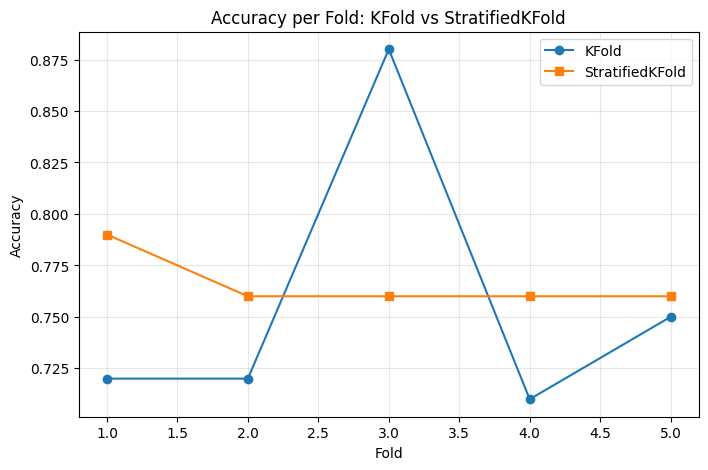

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), accuracies_kfold, marker="o", label="KFold")
plt.plot(range(1, 6), accuracies_strat, marker="s", label="StratifiedKFold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Accuracy per Fold: KFold vs StratifiedKFold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Advanced Cross-Validation Methods

Selain K-Fold dan Stratified K-Fold, terdapat beberapa metode cross-validation lanjutan. Chapter ini menekankan dua metode:

1. **Leave-One-Out Cross-Validation (LOOCV)**
2. **Nested Cross-Validation**

LOOCV cocok ketika dataset kecil dan setiap data ingin dimanfaatkan semaksimal mungkin. Nested CV cocok ketika model selection dan hyperparameter tuning perlu dievaluasi secara adil tanpa data leakage.

## Leave-One-Out Cross-Validation

Leave-One-Out Cross-Validation adalah bentuk ekstrem dari K-Fold, di mana jumlah fold sama dengan jumlah data.

Jika dataset memiliki $n$ sampel, maka LOOCV melakukan $n$ kali training:
- $n-1$ sampel untuk training
- 1 sampel untuk testing

Kelebihan:
- Memanfaatkan data training secara maksimal.
- Hampir semua data dipakai untuk training pada setiap iterasi.

Kekurangan:
- Sangat mahal secara komputasi.
- Bisa memiliki variance tinggi.
- Tidak praktis untuk dataset besar.

## Rumus Jumlah Iterasi LOOCV

Jika terdapat $n$ sampel, jumlah model yang dilatih dalam LOOCV adalah:

$$
Jumlah\ Iterasi = n
$$

Pada setiap iterasi:

$$
Training\ Size = n - 1
$$

$$
Validation\ Size = 1
$$

Contoh: jika dataset memiliki 442 sampel, maka model dilatih 442 kali.

## Load Diabetes Dataset untuk LOOCV

Dataset diabetes digunakan untuk demonstrasi regresi dengan Ridge Regression.

In [8]:
diabetes = load_diabetes()

X_diabetes = diabetes.data
y_diabetes = diabetes.target

print("Shape X:", X_diabetes.shape)
print("Shape y:", y_diabetes.shape)

Shape X: (442, 10)
Shape y: (442,)


## Implementasi LOOCV dengan Ridge Regression

Karena LOOCV cukup mahal, proses ini masih aman dijalankan pada dataset diabetes yang berukuran kecil.

In [9]:
loo = LeaveOneOut()
ridge_model = Ridge(alpha=1.0)

scores_loo = cross_val_score(
    ridge_model,
    X_diabetes,
    y_diabetes,
    cv=loo,
    scoring="neg_mean_squared_error"
)

loocv_mse = -np.mean(scores_loo)

print(f"Jumlah iterasi LOOCV: {len(scores_loo)}")
print(f"LOOCV mean MSE: {loocv_mse:.3f}")
print(f"LOOCV RMSE: {np.sqrt(loocv_mse):.3f}")

Jumlah iterasi LOOCV: 442
LOOCV mean MSE: 3327.655
LOOCV RMSE: 57.686


## Analisis LOOCV

LOOCV memberikan estimasi performa dengan menggunakan hampir seluruh data untuk training. Namun, biayanya tinggi karena model harus dilatih sebanyak jumlah sampel.

Jika dataset besar, K-Fold biasa seperti 5-fold atau 10-fold sering lebih praktis.

## Nested Cross-Validation

Nested Cross-Validation digunakan ketika kita ingin melakukan hyperparameter tuning sekaligus mengevaluasi model secara adil.

Masalah umum:
- Jika kita melakukan GridSearchCV dan langsung melaporkan score terbaik, score tersebut bisa terlalu optimistis.
- Model sudah “memilih” parameter berdasarkan data validasi.
- Jika data validasi yang sama dipakai untuk evaluasi akhir, terjadi bias evaluasi.

Nested CV menyelesaikan masalah ini dengan dua loop:

| Loop | Fungsi |
|---|---|
| Inner loop | Hyperparameter tuning |
| Outer loop | Evaluasi generalisasi model |

## Struktur Nested Cross-Validation

Secara konseptual:

$$
Outer\ CV:
\quad
Train_{outer}, Test_{outer}
$$

Di dalam setiap training outer fold:

$$
Inner\ CV:
\quad
Model\ Selection\ atau\ Hyperparameter\ Tuning
$$

Setelah parameter terbaik dipilih pada inner loop, model dievaluasi pada outer test fold. Dengan begitu, test fold luar tidak ikut digunakan dalam proses pemilihan parameter.

## Implementasi Nested CV dengan Ridge Regression

Ridge Regression memiliki hyperparameter `alpha`. Inner loop memilih `alpha`, sedangkan outer loop mengevaluasi performa model.

In [10]:
param_grid_ridge = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

inner_grid = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    cv=5,
    scoring="r2"
)

nested_scores = cross_val_score(
    inner_grid,
    X_diabetes,
    y_diabetes,
    cv=5,
    scoring="r2"
)

print("Nested CV R2 scores:", nested_scores)
print(f"Nested CV mean R2: {np.mean(nested_scores):.3f}")
print(f"Nested CV std R2: {np.std(nested_scores):.3f}")

Nested CV R2 scores: [0.41127194 0.52005013 0.49219156 0.44044195 0.53702921]
Nested CV mean R2: 0.480
Nested CV std R2: 0.048


## Analisis Nested CV

Nested CV memberi estimasi performa yang lebih jujur karena proses tuning tidak mencemari fold evaluasi luar. Teknik ini sangat berguna ketika kita membandingkan beberapa model atau banyak konfigurasi hyperparameter.

Kekurangannya adalah biaya komputasi lebih tinggi karena GridSearchCV dijalankan di dalam setiap outer fold.

## Model Evaluation Metrics Overview

Metrik evaluasi harus dipilih sesuai tujuan masalah. Accuracy tidak selalu cukup, terutama ketika dataset imbalanced.

Contoh:
- Pada fraud detection, recall penting agar fraud tidak terlewat.
- Pada sistem rekomendasi medis, false negative bisa lebih berbahaya daripada false positive.
- Pada email spam, precision penting agar email penting tidak salah masuk spam.

Metrik yang umum:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- MSE
- RMSE
- MAE
- R²

## Rumus Accuracy, Precision, Recall, dan F1

### Accuracy

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

### Precision

$$
Precision = \frac{TP}{TP + FP}
$$

### Recall

$$
Recall = \frac{TP}{TP + FN}
$$

### F1-Score

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

Keterangan:

- $TP$ = True Positive
- $TN$ = True Negative
- $FP$ = False Positive
- $FN$ = False Negative

F1-score berguna ketika precision dan recall sama-sama penting.

## Rumus Metrik Regresi

### Mean Squared Error

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

### Root Mean Squared Error

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

### Mean Absolute Error

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

### R-Squared

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}
$$

Keterangan:

- $y_i$ = nilai aktual
- $\hat{y}_i$ = nilai prediksi
- $\bar{y}$ = rata-rata target aktual

## Dataset Imbalanced untuk Evaluasi Metrik

Dataset berikut dibuat dengan distribusi kelas 70% dan 30%. Tujuannya adalah menunjukkan bahwa accuracy tidak selalu cukup.

In [11]:
X_imb, y_imb = make_classification(
    n_samples=500,
    n_features=10,
    weights=[0.7, 0.3],
    random_state=2024
)

print("Distribusi kelas:", np.bincount(y_imb))

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb,
    y_imb,
    test_size=0.3,
    random_state=2024,
    stratify=y_imb
)

Distribusi kelas: [350 150]


In [12]:
metric_model = LogisticRegression(max_iter=1000)
metric_model.fit(X_train_imb, y_train_imb)

y_pred_imb = metric_model.predict(X_test_imb)
y_proba_imb = metric_model.predict_proba(X_test_imb)[:, 1]

metrics_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test_imb, y_pred_imb),
        precision_score(y_test_imb, y_pred_imb),
        recall_score(y_test_imb, y_pred_imb),
        f1_score(y_test_imb, y_pred_imb),
        roc_auc_score(y_test_imb, y_proba_imb)
    ]
})

metrics_summary

,Metric,Value
0,Accuracy,0.913333
1,Precision,0.900000
2,Recall,0.800000
3,F1-score,0.847059
4,ROC-AUC,0.961905


In [13]:
print(classification_report(y_test_imb, y_pred_imb))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       105
           1       0.90      0.80      0.85        45

    accuracy                           0.91       150
   macro avg       0.91      0.88      0.89       150
weighted avg       0.91      0.91      0.91       150



## Confusion Matrix

Confusion matrix membantu melihat jenis kesalahan model. Pada dataset imbalanced, jumlah kesalahan pada kelas minoritas sering lebih penting daripada accuracy total.

,Predicted Class 0,Predicted Class 1
True Class 0,101,4
True Class 1,9,36


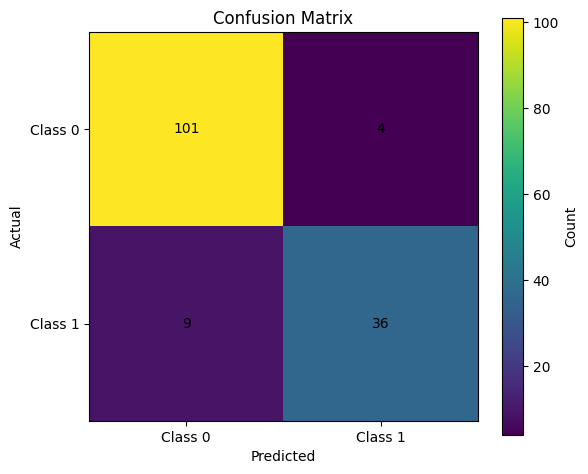

In [14]:
cm = confusion_matrix(y_test_imb, y_pred_imb)

cm_df = pd.DataFrame(
    cm,
    index=["True Class 0", "True Class 1"],
    columns=["Predicted Class 0", "Predicted Class 1"]
)

display(cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])
plt.colorbar(label="Count")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## ROC Curve

ROC curve menunjukkan hubungan antara True Positive Rate dan False Positive Rate pada berbagai threshold.

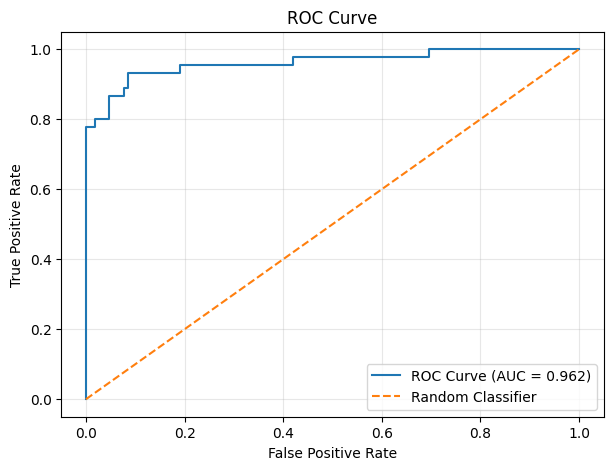

In [15]:
fpr, tpr, thresholds = roc_curve(y_test_imb, y_proba_imb)
auc_score = roc_auc_score(y_test_imb, y_proba_imb)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Implementing Cross-Validation in scikit-learn

Scikit-learn menyediakan beberapa API praktis untuk cross-validation:

| Fungsi | Kegunaan |
|---|---|
| `cross_val_score()` | Evaluasi model dengan satu metrik |
| `cross_validate()` | Evaluasi model dengan banyak metrik sekaligus |
| `GridSearchCV()` | Hyperparameter tuning dengan cross-validation |
| `RandomizedSearchCV()` | Tuning dengan sampling acak dari distribusi parameter |

Fungsi-fungsi ini membuat workflow evaluasi model lebih ringkas dan lebih mudah direproduksi.

## cross_val_score()

`cross_val_score()` digunakan ketika kita hanya membutuhkan satu metrik evaluasi.

In [16]:
model = LogisticRegression(max_iter=1000)

scores_accuracy = cross_val_score(
    model,
    X_imb,
    y_imb,
    cv=5,
    scoring="accuracy"
)

print("Accuracy per fold:", scores_accuracy)
print(f"Mean accuracy: {np.mean(scores_accuracy):.3f}")
print(f"Std accuracy: {np.std(scores_accuracy):.3f}")

Accuracy per fold: [0.87 0.92 0.87 0.95 0.94]
Mean accuracy: 0.910
Std accuracy: 0.034


## cross_validate()

`cross_validate()` lebih fleksibel karena dapat menghitung beberapa metrik sekaligus.

In [17]:
results = cross_validate(
    model,
    X_imb,
    y_imb,
    cv=5,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=True
)

cv_results_df = pd.DataFrame(results)
cv_results_df

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1
0,0.006790,0.010550,0.87,0.9375,0.840000,0.935780,0.700000,0.850000,0.763636,0.890830
1,0.006083,0.009544,0.92,0.9275,0.923077,0.917431,0.800000,0.833333,0.857143,0.873362
2,0.005717,0.010936,0.87,0.9300,0.774194,0.910714,0.800000,0.850000,0.786885,0.879310
3,0.005478,0.009758,0.95,0.9225,0.962963,0.923810,0.866667,0.808333,0.912281,0.862222
4,0.006188,0.028799,0.94,0.9225,0.875000,0.915888,0.933333,0.816667,0.903226,0.863436


In [18]:
multi_metric_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Mean Test Score": [
        np.mean(results["test_accuracy"]),
        np.mean(results["test_precision"]),
        np.mean(results["test_recall"]),
        np.mean(results["test_f1"])
    ],
    "Std Test Score": [
        np.std(results["test_accuracy"]),
        np.std(results["test_precision"]),
        np.std(results["test_recall"]),
        np.std(results["test_f1"])
    ]
})

multi_metric_summary

,Metric,Mean Test Score,Std Test Score
0,Accuracy,0.910000,0.034059
1,Precision,0.875047,0.065476
2,Recall,0.820000,0.077746
3,F1,0.844634,0.060102


## Analisis cross_validate()

Dengan `cross_validate()`, kita dapat melihat beberapa metrik sekaligus. Ini penting karena model dengan accuracy tinggi belum tentu memiliki recall tinggi pada kelas minoritas.

Jika tujuan sistem adalah mengurangi false negative, recall lebih penting. Jika tujuan sistem adalah mengurangi false positive, precision lebih penting.

## Model Selection Techniques

Model selection adalah proses memilih model atau konfigurasi model terbaik berdasarkan evaluasi yang robust. Dalam praktik, pemilihan model tidak hanya berdasarkan score teknis, tetapi juga:
- biaya kesalahan prediksi,
- waktu training,
- interpretabilitas,
- kemudahan deployment,
- kestabilan performa,
- kebutuhan bisnis.

Namun, dari sisi teknis, GridSearchCV dan RandomizedSearchCV adalah dua alat utama untuk model selection.

## GridSearchCV

GridSearchCV mencoba semua kombinasi hyperparameter dalam parameter grid. Teknik ini komprehensif, tetapi bisa mahal jika jumlah kombinasi besar.

Jika terdapat $a$ nilai untuk parameter pertama dan $b$ nilai untuk parameter kedua, jumlah kombinasi adalah:

$$
Total\ Kombinasi = a \times b
$$

Untuk banyak parameter:

$$
Total\ Kombinasi = \prod_{i=1}^{p} n_i
$$

Keterangan:

- $p$ = jumlah hyperparameter
- $n_i$ = jumlah kandidat nilai pada hyperparameter ke-$i$

In [19]:
X_search, y_search = make_classification(
    n_samples=500,
    n_features=10,
    weights=[0.7, 0.3],
    random_state=2024
)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_search,
    y_search,
    test_size=0.3,
    random_state=2024,
    stratify=y_search
)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_s, y_train_s)

print("GridSearchCV best C:", grid.best_params_["C"])
print(f"GridSearchCV best CV accuracy: {grid.best_score_:.3f}")

grid_pred = grid.predict(X_test_s)

print(f"GridSearchCV test accuracy: {accuracy_score(y_test_s, grid_pred):.3f}")

GridSearchCV best C: 1
GridSearchCV best CV accuracy: 0.923
GridSearchCV test accuracy: 0.913


In [20]:
grid_results_df = pd.DataFrame(grid.cv_results_)

grid_results_df[[
    "param_C",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

,param_C,mean_test_score,std_test_score,rank_test_score
3,1.000,0.922857,0.027994,1
4,10.000,0.917143,0.033074,2
5,100.000,0.917143,0.033074,2
2,0.100,0.911429,0.027701,4
1,0.010,0.871429,0.015649,5
0,0.001,0.700000,0.000000,6


## RandomizedSearchCV

RandomizedSearchCV mengambil sampel acak dari distribusi parameter. Teknik ini sering lebih efisien jika search space besar atau parameter bersifat kontinu.

Berbeda dari GridSearchCV yang mencoba semua kombinasi, RandomizedSearchCV mencoba sebanyak `n_iter` kombinasi.

Keunggulan:
- Lebih hemat waktu.
- Cocok untuk distribusi kontinu.
- Bisa menemukan konfigurasi bagus tanpa exhaustive search.

In [21]:
param_dist = {
    "C": loguniform(1e-3, 1e2)
}

random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=2024
)

random_search.fit(X_train_s, y_train_s)

print(f"RandomizedSearchCV best C: {random_search.best_params_['C']:.4f}")
print(f"RandomizedSearchCV best CV accuracy: {random_search.best_score_:.3f}")

random_pred = random_search.predict(X_test_s)

print(f"RandomizedSearchCV test accuracy: {accuracy_score(y_test_s, random_pred):.3f}")

RandomizedSearchCV best C: 0.8711
RandomizedSearchCV best CV accuracy: 0.920
RandomizedSearchCV test accuracy: 0.913


In [22]:
random_results_df = pd.DataFrame(random_search.cv_results_)

random_results_df[[
    "param_C",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)

,param_C,mean_test_score,std_test_score,rank_test_score
0,0.871109,0.920000,0.027994,1
1,3.129996,0.917143,0.033074,2
6,4.327138,0.917143,0.033074,2
7,2.494610,0.917143,0.033074,2
8,0.234007,0.914286,0.028571,5
9,0.174373,0.911429,0.027701,6
4,0.010595,0.874286,0.013997,7
2,0.008725,0.862857,0.019378,8
5,0.003391,0.760000,0.018952,9
3,0.001656,0.711429,0.010690,10


## Perbandingan Grid Search dan Randomized Search

Tabel berikut membandingkan performa model hasil GridSearchCV dan RandomizedSearchCV.

In [23]:
search_comparison = pd.DataFrame([
    {
        "Method": "GridSearchCV",
        "Best C": grid.best_params_["C"],
        "Best CV Accuracy": grid.best_score_,
        "Test Accuracy": accuracy_score(y_test_s, grid_pred)
    },
    {
        "Method": "RandomizedSearchCV",
        "Best C": random_search.best_params_["C"],
        "Best CV Accuracy": random_search.best_score_,
        "Test Accuracy": accuracy_score(y_test_s, random_pred)
    }
])

search_comparison

,Method,Best C,Best CV Accuracy,Test Accuracy
0,GridSearchCV,1.000000,0.922857,0.913333
1,RandomizedSearchCV,0.871109,0.920000,0.913333


## Model Selection dengan Banyak Model

Model selection tidak selalu hanya memilih hyperparameter untuk satu model. Kita juga bisa membandingkan beberapa algoritma menggunakan cross-validation.

In [24]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "Random Forest": RandomForestClassifier(random_state=2024),
    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=2024))
    ])
}

model_selection_results = []

for name, estimator in models.items():
    scores = cross_validate(
        estimator,
        X_imb,
        y_imb,
        cv=5,
        scoring=["accuracy", "precision", "recall", "f1"]
    )

    model_selection_results.append({
        "Model": name,
        "Accuracy": np.mean(scores["test_accuracy"]),
        "Precision": np.mean(scores["test_precision"]),
        "Recall": np.mean(scores["test_recall"]),
        "F1-score": np.mean(scores["test_f1"])
    })

model_selection_df = pd.DataFrame(model_selection_results).sort_values("F1-score", ascending=False)
model_selection_df

,Model,Accuracy,Precision,Recall,F1-score
1,Random Forest,0.920,0.907937,0.813333,0.857404
0,Logistic Regression,0.908,0.873541,0.813333,0.840590
2,SVC,0.910,0.909852,0.780000,0.836228


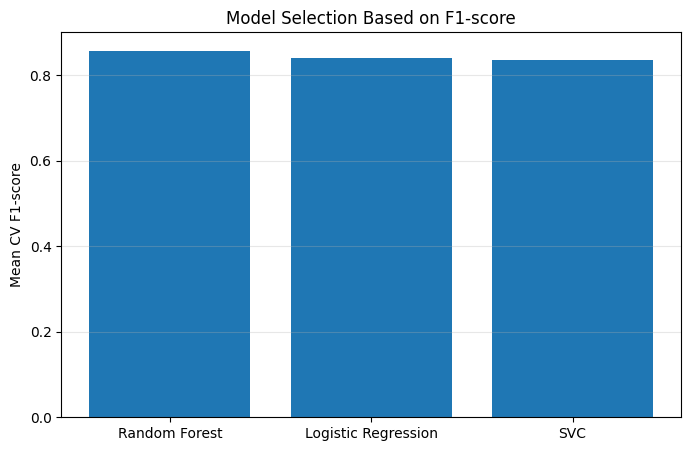

In [25]:
plt.figure(figsize=(8, 5))
plt.bar(model_selection_df["Model"], model_selection_df["F1-score"])
plt.ylabel("Mean CV F1-score")
plt.title("Model Selection Based on F1-score")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Evaluating Model Generalizability

Model yang baik pada training set belum tentu baik pada data baru. Generalizability adalah kemampuan model untuk mempertahankan performa pada data yang belum pernah dilihat.

Beberapa tanda masalah generalisasi:

| Kondisi | Interpretasi |
|---|---|
| Training score tinggi, validation score rendah | Overfitting |
| Training score rendah, validation score rendah | Underfitting |
| Training dan validation score sama-sama tinggi | Generalisasi baik |
| Score antar fold sangat bervariasi | Model tidak stabil atau data terlalu kecil |

Learning curve dan validation curve membantu mendiagnosis kondisi tersebut.

## Learning Curve

Learning curve menunjukkan bagaimana performa model berubah ketika jumlah data training meningkat.

Learning curve menjawab pertanyaan:
- Apakah model akan membaik jika diberi lebih banyak data?
- Apakah model overfitting?
- Apakah model underfitting?
- Apakah performa sudah plateau?

Jika training score dan validation score mulai konvergen, model cenderung memiliki generalisasi lebih baik.

## Rumus Train dan Validation Score Gap

Gap antara training dan validation score dapat dihitung sebagai:

$$
Gap = Train\ Score - Validation\ Score
$$

Interpretasi:

- Gap besar: kemungkinan overfitting.
- Gap kecil tetapi score rendah: kemungkinan underfitting.
- Gap kecil dan score tinggi: generalisasi baik.

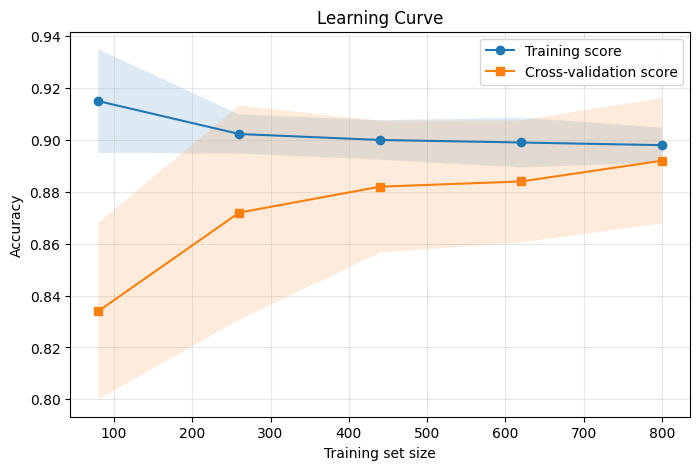

,train_size,train_score_mean,cv_score_mean,gap
0,80,0.915000,0.834,0.081000
1,260,0.902308,0.872,0.030308
2,440,0.900000,0.882,0.018000
3,620,0.899032,0.884,0.015032
4,800,0.898000,0.892,0.006000


In [26]:
X_gen, y_gen = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.7, 0.3],
    random_state=2024
)

train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=1000),
    X_gen,
    y_gen,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.plot(train_sizes, test_mean, marker="s", label="Cross-validation score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

learning_curve_df = pd.DataFrame({
    "train_size": train_sizes,
    "train_score_mean": train_mean,
    "cv_score_mean": test_mean,
    "gap": train_mean - test_mean
})

learning_curve_df

## Analisis Learning Curve

Jika validation score meningkat saat training size bertambah, artinya model mendapat manfaat dari tambahan data. Jika kedua kurva mulai mendekat, model lebih stabil dalam melakukan generalisasi.

Jika setelah titik tertentu score tidak naik signifikan, berarti ada diminishing returns. Dalam kondisi ini, menambah data mungkin tidak lagi memberi peningkatan besar, sehingga lebih baik mencoba feature engineering, model lain, atau tuning parameter.

## Validation Curve

Validation curve menunjukkan bagaimana performa berubah ketika satu hyperparameter diubah.

Pada Logistic Regression, parameter `C` adalah inverse regularization strength:

$$
C = \frac{1}{\lambda}
$$

Keterangan:

- $C$ besar berarti regularization lebih lemah.
- $C$ kecil berarti regularization lebih kuat.

Jika `C` terlalu kecil, model bisa underfitting. Jika `C` terlalu besar, model bisa overfitting.

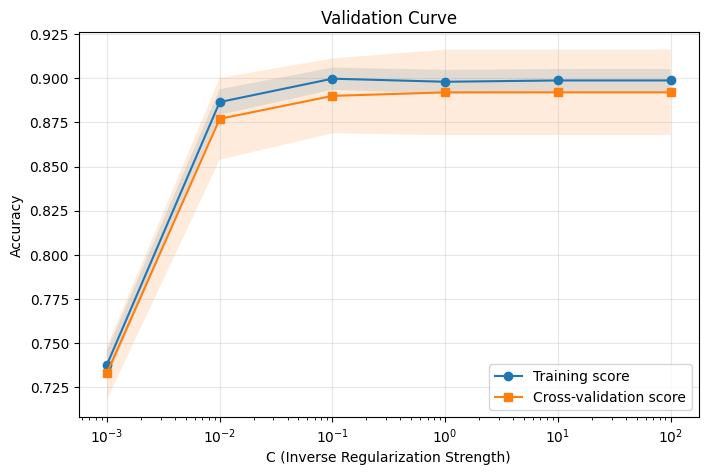

,C,train_score_mean,cv_score_mean,gap
0,0.001,0.73775,0.733,0.00475
1,0.010,0.88650,0.877,0.00950
2,0.100,0.89975,0.890,0.00975
3,1.000,0.89800,0.892,0.00600
4,10.000,0.89875,0.892,0.00675
5,100.000,0.89875,0.892,0.00675


In [27]:
param_range = np.logspace(-3, 2, 6)

train_scores_v, test_scores_v = validation_curve(
    LogisticRegression(max_iter=1000),
    X_gen,
    y_gen,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

train_mean_v = np.mean(train_scores_v, axis=1)
test_mean_v = np.mean(test_scores_v, axis=1)
train_std_v = np.std(train_scores_v, axis=1)
test_std_v = np.std(test_scores_v, axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(param_range, train_mean_v, marker="o", label="Training score")
plt.semilogx(param_range, test_mean_v, marker="s", label="Cross-validation score")
plt.fill_between(param_range, train_mean_v - train_std_v, train_mean_v + train_std_v, alpha=0.15)
plt.fill_between(param_range, test_mean_v - test_std_v, test_mean_v + test_std_v, alpha=0.15)
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Validation Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

validation_curve_df = pd.DataFrame({
    "C": param_range,
    "train_score_mean": train_mean_v,
    "cv_score_mean": test_mean_v,
    "gap": train_mean_v - test_mean_v
})

validation_curve_df

## Analisis Validation Curve

Validation curve membantu melihat nilai hyperparameter yang memberikan performa terbaik. Jika training score tinggi tetapi validation score rendah, model mungkin terlalu kompleks. Jika keduanya rendah, regularization terlalu kuat atau model terlalu sederhana.

Pada Logistic Regression:
- `C` kecil berarti regularization kuat.
- `C` besar berarti regularization lemah.
- Nilai terbaik biasanya berada ketika validation score tinggi dan gap tidak terlalu besar.

## Practical Exercise 1: Cross-validating Logistic Regression

Latihan ini mengevaluasi Logistic Regression menggunakan cross-validation dan beberapa metrik sekaligus.

In [28]:
exercise_model = LogisticRegression(max_iter=1000)

exercise_scores = cross_validate(
    exercise_model,
    X_imb,
    y_imb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=2024),
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

exercise_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Mean": [
        exercise_scores["test_accuracy"].mean(),
        exercise_scores["test_precision"].mean(),
        exercise_scores["test_recall"].mean(),
        exercise_scores["test_f1"].mean(),
        exercise_scores["test_roc_auc"].mean()
    ],
    "Std": [
        exercise_scores["test_accuracy"].std(),
        exercise_scores["test_precision"].std(),
        exercise_scores["test_recall"].std(),
        exercise_scores["test_f1"].std(),
        exercise_scores["test_roc_auc"].std()
    ]
})

exercise_summary

,Metric,Mean,Std
0,Accuracy,0.914000,0.018547
1,Precision,0.915817,0.026259
2,Recall,0.786667,0.065320
3,F1-score,0.844569,0.037323
4,ROC-AUC,0.962095,0.022290


## Practical Exercise 2: Hyperparameter Tuning dengan Grid Search

Latihan ini menggunakan GridSearchCV untuk memilih nilai `C` terbaik pada Logistic Regression.

In [29]:
exercise_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

exercise_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

exercise_grid = GridSearchCV(
    exercise_pipe,
    exercise_param_grid,
    cv=5,
    scoring="f1"
)

exercise_grid.fit(X_train_s, y_train_s)

exercise_grid_pred = exercise_grid.predict(X_test_s)

print("Best parameters:", exercise_grid.best_params_)
print(f"Best CV F1: {exercise_grid.best_score_:.3f}")
print(f"Test F1: {f1_score(y_test_s, exercise_grid_pred):.3f}")
print(f"Test Accuracy: {accuracy_score(y_test_s, exercise_grid_pred):.3f}")

Best parameters: {'model__C': 1}
Best CV F1: 0.860
Test F1: 0.847
Test Accuracy: 0.913


## Practical Exercise 3: Learning dan Validation Curves

Latihan ini menggabungkan learning curve dan validation curve sebagai alat diagnosis generalisasi model.

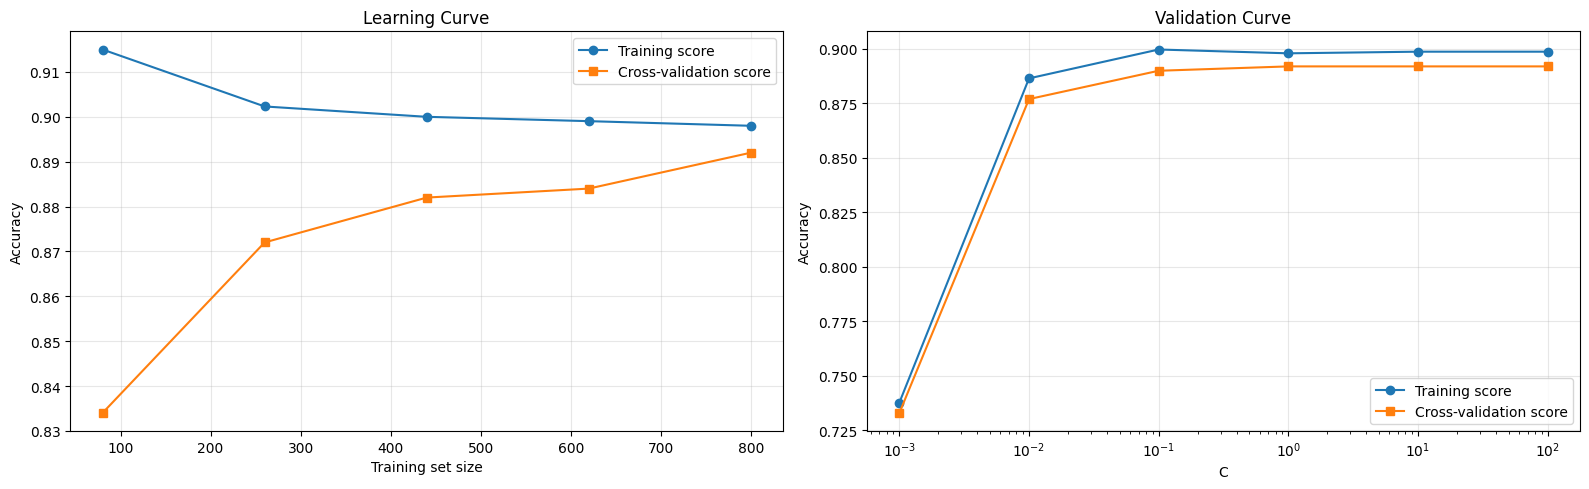

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_sizes, train_mean, marker="o", label="Training score")
axes[0].plot(train_sizes, test_mean, marker="s", label="Cross-validation score")
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Learning Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].semilogx(param_range, train_mean_v, marker="o", label="Training score")
axes[1].semilogx(param_range, test_mean_v, marker="s", label="Cross-validation score")
axes[1].set_xlabel("C")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Best Practices Cross-Validation dan Model Evaluation

Beberapa praktik penting:

| Praktik | Alasan |
|---|---|
| Gunakan stratified CV untuk klasifikasi | Menjaga proporsi kelas |
| Jangan tuning pada test set | Menghindari evaluasi terlalu optimistis |
| Gunakan nested CV untuk evaluasi tuning yang adil | Mencegah data leakage |
| Gunakan metrik sesuai tujuan | Accuracy tidak selalu cukup |
| Laporkan mean dan std CV score | Menunjukkan performa dan stabilitas |
| Gunakan pipeline | Menghindari leakage saat preprocessing |
| Gunakan learning curve | Menilai kebutuhan data tambahan |
| Gunakan validation curve | Menilai pengaruh hyperparameter |

Cross-validation bukan hanya prosedur teknis, tetapi bagian dari metodologi evaluasi agar model lebih dapat dipercaya.

## Kesalahan Umum dalam Evaluasi Model

| Kesalahan | Dampak |
|---|---|
| Menggunakan test set untuk tuning | Estimasi performa menjadi terlalu optimistis |
| Melakukan scaling sebelum split/CV | Data leakage |
| Hanya melihat accuracy | Metrik bisa menyesatkan pada imbalanced data |
| Tidak menggunakan stratification | Fold dapat tidak representatif |
| Tidak melaporkan variasi score | Stabilitas model tidak terlihat |
| Mengabaikan business metric | Model bagus secara teknis belum tentu berguna |
| Tidak mengevaluasi model setelah deployment | Perubahan data dapat menurunkan performa |

Evaluasi model harus memperhatikan konteks penggunaan, bukan hanya angka score.

## Ringkasan Konsep Penting

| Konsep | Penjelasan |
|---|---|
| Cross-Validation | Evaluasi model dengan beberapa pembagian data |
| K-Fold | Membagi data menjadi k fold |
| Stratified K-Fold | Menjaga proporsi kelas pada setiap fold |
| LOOCV | Satu data menjadi test set pada setiap iterasi |
| Nested CV | Inner loop untuk tuning, outer loop untuk evaluasi |
| cross_val_score | Evaluasi satu metrik |
| cross_validate | Evaluasi banyak metrik |
| GridSearchCV | Mencoba semua kombinasi parameter |
| RandomizedSearchCV | Sampling kombinasi parameter secara acak |
| Accuracy | Proporsi prediksi benar |
| Precision | Ketepatan prediksi positif |
| Recall | Kemampuan menemukan kelas positif |
| F1-score | Harmonic mean precision dan recall |
| Learning Curve | Pengaruh jumlah data training terhadap score |
| Validation Curve | Pengaruh hyperparameter terhadap score |
| Generalization | Kemampuan model bekerja pada data baru |

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa evaluasi model adalah bagian penting dalam machine learning. Model yang terlihat bagus pada satu pembagian data belum tentu benar-benar mampu melakukan generalisasi. Cross-validation membantu memperoleh estimasi performa yang lebih stabil dengan melatih dan mengevaluasi model pada beberapa subset data.

Poin penting dari chapter ini:

- Cross-validation lebih informatif dibanding satu train-test split.
- K-Fold membagi data menjadi beberapa fold, sedangkan Stratified K-Fold menjaga proporsi kelas.
- LOOCV memanfaatkan data secara maksimal tetapi mahal secara komputasi.
- Nested Cross-Validation membantu mengevaluasi model tuning secara lebih jujur.
- `cross_val_score()` cocok untuk satu metrik, sedangkan `cross_validate()` cocok untuk banyak metrik.
- GridSearchCV melakukan pencarian menyeluruh terhadap parameter grid.
- RandomizedSearchCV lebih efisien untuk search space besar atau parameter kontinu.
- Accuracy tidak selalu menjadi metrik terbaik, terutama pada dataset imbalanced.
- Learning curve membantu menilai apakah model membutuhkan lebih banyak data.
- Validation curve membantu memahami pengaruh hyperparameter terhadap underfitting dan overfitting.
- Evaluasi model harus memperhatikan konteks bisnis, konsekuensi false positive/false negative, dan kemampuan generalisasi.

Secara keseluruhan, cross-validation dan evaluasi model merupakan fondasi penting agar model machine learning tidak hanya terlihat bagus pada eksperimen, tetapi juga lebih siap digunakan pada data nyata.